In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [3]:
news_df = pd.read_csv("/Users/rishaan/Downloads/news_articles.csv")
train_users = pd.read_csv("/Users/rishaan/Downloads/train_users.csv")
test_users = pd.read_csv("/Users/rishaan/Downloads/test_users.csv")
print("Train shape:", train_users.shape)
print("Test shape:", test_users.shape)
print("Columns:", train_users.columns)

Train shape: (2000, 33)
Test shape: (2000, 32)
Columns: Index(['user_id', 'age', 'income', 'clicks', 'purchase_amount',
       'session_duration', 'content_variety', 'engagement_score',
       'num_transactions', 'avg_monthly_spend', 'avg_cart_value',
       'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site',
       'interaction_count', 'preferred_price_range', 'discount_usage_rate',
       'wishlist_size', 'product_views', 'repeat_purchase_gap (days)',
       'churn_risk_score', 'loyalty_index', 'screen_brightness',
       'battery_percentage', 'cart_abandonment_count', 'browser_version',
       'background_app_count', 'session_inactivity_duration', 'network_jitter',
       'region_code', 'subscriber', 'label'],
      dtype='object')


In [4]:
train_users = train_users.dropna()
test_users = test_users.dropna()
TARGET = "label"
y = train_users[TARGET]
X = train_users.drop(TARGET, axis=1)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
if len(categorical_cols) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[categorical_cols] = encoder.fit_transform(X[categorical_cols])
    test_users[categorical_cols] = encoder.transform(test_users[categorical_cols])
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class balance
)

In [6]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

print(classification_report(y_val, y_pred))
accuracy = clf.score(X_val, y_val)
print("Validation Accuracy:", accuracy)
""

              precision    recall  f1-score   support

           0       0.88      0.81      0.85       113
           1       0.89      0.92      0.90       126
           2       0.54      0.64      0.58        22

    accuracy                           0.85       261
   macro avg       0.77      0.79      0.78       261
weighted avg       0.86      0.85      0.85       261

Validation Accuracy: 0.8505747126436781


''

In [10]:
from rlcmab_sampler import sampler
ROLL_NUMBER = 47   
reward_sampler = sampler(ROLL_NUMBER)
T = 10000
NUM_CONTEXTS = 3
NUM_ARMS = 4
def get_global_arm(context, local_arm):
    return context * NUM_ARMS + local_arm
class EpsilonGreedy:
    def __init__(self, epsilon):
        self.epsilon = epsilon
        self.q = np.zeros(NUM_ARMS)
        self.n = np.zeros(NUM_ARMS)

    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(NUM_ARMS)
        return np.argmax(self.q)

    def update(self, arm, reward):
        self.n[arm] += 1
        self.q[arm] += (reward - self.q[arm]) / self.n[arm]


In [11]:
def run_epsilon(context, epsilon):
    agent = EpsilonGreedy(epsilon)
    rewards = []

    for t in range(T):
        arm = agent.select_arm()
        global_arm = get_global_arm(context, arm)

        reward = reward_sampler.sample(global_arm)
        agent.update(arm, reward)

        rewards.append(reward)

    return np.cumsum(rewards) / (np.arange(T) + 1), agent.q
epsilons = [0.01, 0.1, 0.2]

epsilon_results = {}
epsilon_expected_rewards = {}

for context in range(NUM_CONTEXTS):
    epsilon_results[context] = {}
    epsilon_expected_rewards[context] = {}

    for eps in epsilons:
        avg_reward_curve, q_values = run_epsilon(context, eps)
        epsilon_results[context][eps] = avg_reward_curve
        epsilon_expected_rewards[context][eps] = q_values


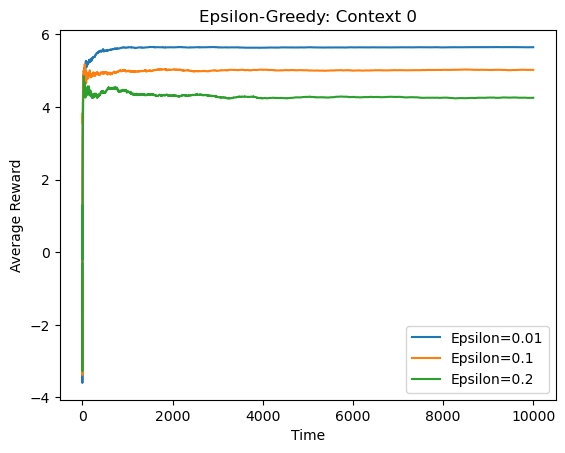

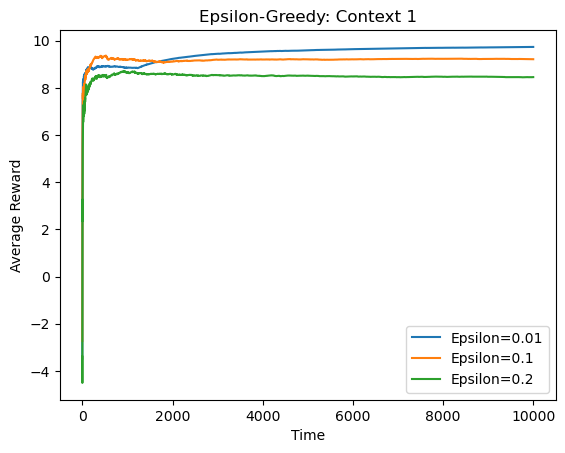

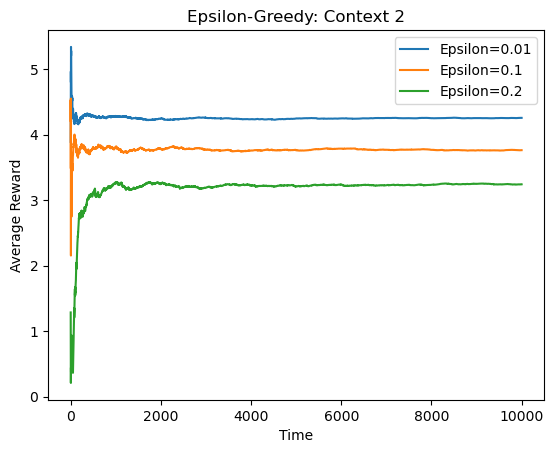

In [14]:
for context in range(NUM_CONTEXTS):
    plt.figure()
    for eps in epsilons:
        plt.plot(epsilon_results[context][eps], label=f"Epsilon={eps}")

    plt.title(f"Epsilon-Greedy: Context {context}")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


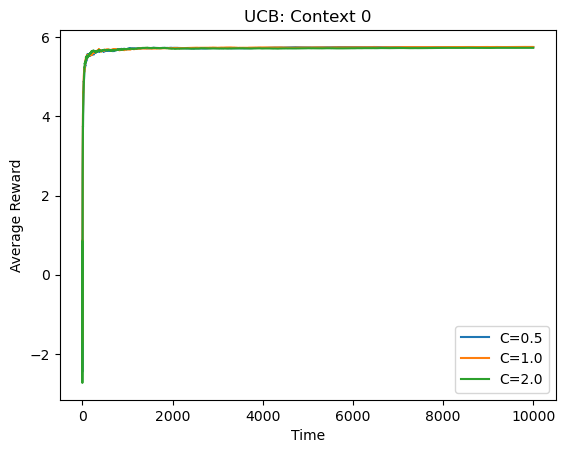

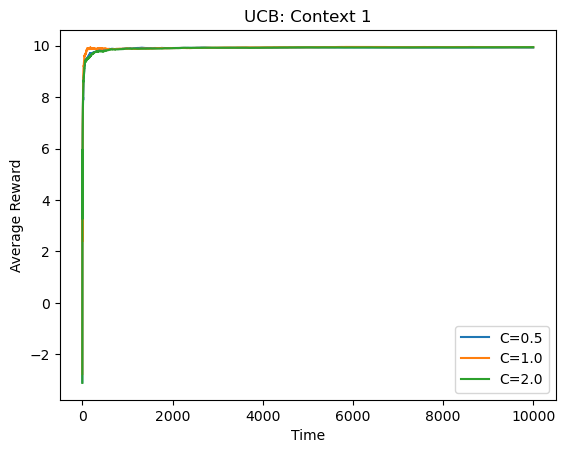

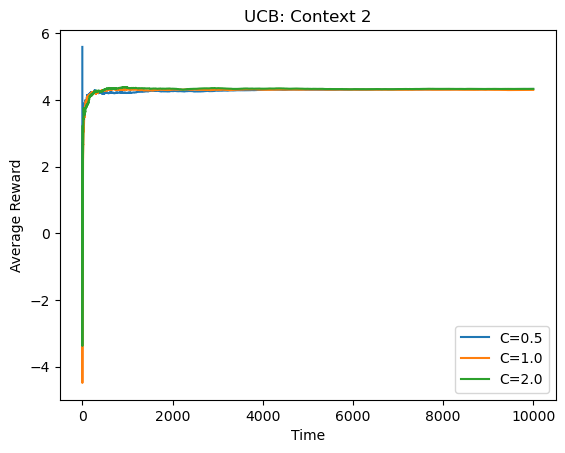

In [15]:
class UCB:
    def __init__(self, C):
        self.C = C
        self.q = np.zeros(NUM_ARMS)
        self.n = np.zeros(NUM_ARMS)
        self.t = 0

    def select_arm(self):
        self.t += 1

        for i in range(NUM_ARMS):
            if self.n[i] == 0:
                return i

        ucb_values = self.q + self.C * np.sqrt(np.log(self.t) / self.n)
        return np.argmax(ucb_values)

    def update(self, arm, reward):
        self.n[arm] += 1
        self.q[arm] += (reward - self.q[arm]) / self.n[arm]
def run_ucb(context, C):
    agent = UCB(C)
    rewards = []

    for t in range(T):
        arm = agent.select_arm()
        global_arm = get_global_arm(context, arm)

        reward = reward_sampler.sample(global_arm)
        agent.update(arm, reward)

        rewards.append(reward)

    return np.cumsum(rewards) / (np.arange(T) + 1), agent.q
C_values = [0.5, 1.0, 2.0]

ucb_results = {}

for context in range(NUM_CONTEXTS):
    ucb_results[context] = {}

    for C in C_values:
        avg_reward_curve, _ = run_ucb(context, C)
        ucb_results[context][C] = avg_reward_curve
for context in range(NUM_CONTEXTS):
    plt.figure()
    for C in C_values:
        plt.plot(ucb_results[context][C], label=f"C={C}")

    plt.title(f"UCB: Context {context}")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


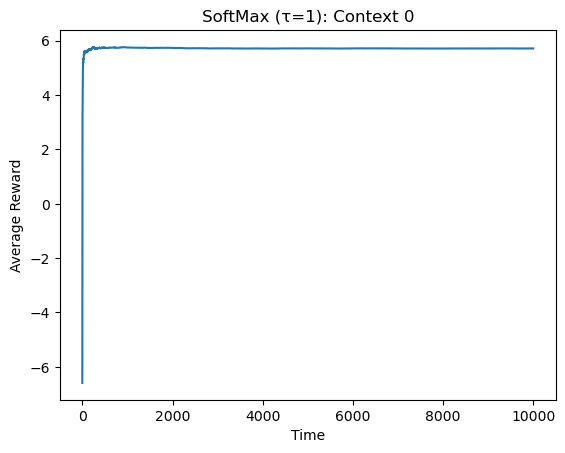

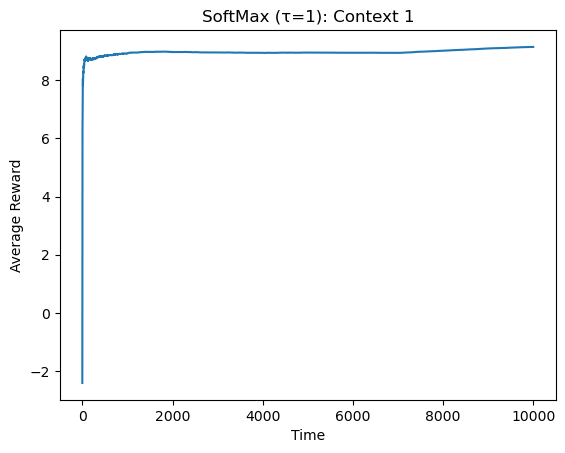

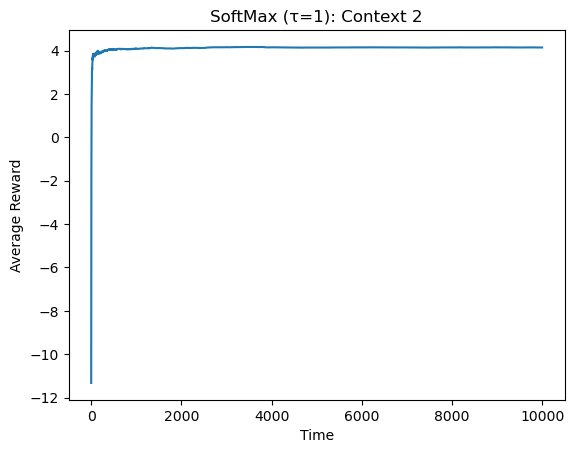

In [16]:
class SoftMax:
    def __init__(self, tau=1):
        self.tau = tau
        self.q = np.zeros(NUM_ARMS)
        self.n = np.zeros(NUM_ARMS)

    def select_arm(self):
        preferences = np.exp(self.q / self.tau)
        probs = preferences / np.sum(preferences)
        return np.random.choice(NUM_ARMS, p=probs)

    def update(self, arm, reward):
        self.n[arm] += 1
        self.q[arm] += (reward - self.q[arm]) / self.n[arm]
def run_softmax(context):
    agent = SoftMax(tau=1)
    rewards = []

    for t in range(T):
        arm = agent.select_arm()
        global_arm = get_global_arm(context, arm)

        reward = reward_sampler.sample(global_arm)
        agent.update(arm, reward)

        rewards.append(reward)

    return np.cumsum(rewards) / (np.arange(T) + 1), agent.q
for context in range(NUM_CONTEXTS):
    avg_reward_curve, _ = run_softmax(context)

    plt.figure()
    plt.plot(avg_reward_curve)
    plt.title(f"SoftMax (τ=1): Context {context}")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.show()
